# User Story Visualization - Gruppe 8, Daniel Iyamu

„Als Taxifahrer möchte ich meine Einnahmen mit dem Branchendurchschnitt vergleichen um meine berufliche Leistung besser bewerten zu können.“

### Data transformation and cleansing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdatesimport 
import seaborn as sns

pd.set_option("display.float_format", "{:.2f}".format)
df = pd.read_parquet("july-25-hv.parquet")
mapping = {
    "HV0002": "Juno",
    "HV0003": "Uber",
    "HV0004": "Via",
    "HV0005": "Lyft"
}

df["hvfhs_license_num"] = df["hvfhs_license_num"].replace(mapping)
df = df.rename(columns={
    "hvfhs_license_num": "Providers",
})
df.drop(["dispatching_base_num","originating_base_num"], axis = 1)
df = df[df['trip_miles'] > 0]
df = df[df['base_passenger_fare'] > 0]
df = df[df['driver_pay'] > 0]



In [ ]:
# --- Zeitspalten in datetime
for col in ["request_datetime","on_scene_datetime","pickup_datetime","dropoff_datetime"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# --- abgeleitete Spalten
df["date"] = df["pickup_datetime"].dt.date
df["hour"] = df["pickup_datetime"].dt.hour
df["dow"]  = df["pickup_datetime"].dt.day_name()

# TLC HVFHS: trip_time ist i.d.R. in Sekunden -> in Stunden umrechnen
df["trip_hours"] = df["trip_time"] / 3600.0

# Vergleichsgröße für Einkommen:
# - "earnings": konservativ nur driver_pay
# - "earnings_plus_tips": driver_pay + tips (falls du Tips separat betrachten willst)
df["tips"] = df["tips"].fillna(0) if "tips" in df.columns else 0
df["earnings"] = df["driver_pay"]
df["earnings_plus_tips"] = df["earnings"] + df["tips"]

# Weitere Kennzahlen je Fahrt
df["earnings_per_mile"] = df["earnings"] / df["trip_miles"]
df["earnings_per_hour_on_trip"] = df["earnings"] / df["trip_hours"]

## Branchendurchschnitt 

In [ ]:
def weighted_hourly(sub):
    """Gewichteter on-trip Stundenverdienst: Sum(earnings) / Sum(trip_hours)."""
    return sub["earnings"].sum() / sub["trip_hours"].sum()

overall_hourly = weighted_hourly(df)
overall_per_mile = df["earnings"].sum() / df["trip_miles"].sum()
overall_per_trip = df["earnings"].mean()

print(f"Branchenmittel (on-trip) Stundenverdienst: ${overall_hourly:,.0f}/h")
print(f"Branchenmittel pro Meile: ${overall_per_mile:,.2f}")
print(f"Branchenmittel pro Fahrt: ${overall_per_trip:,.2f}")


Branchenmittel (on-trip) Stundenverdienst: $63/h
Branchenmittel pro Meile: $4.06
Branchenmittel pro Fahrt: $20.74


## Anbieter‑Vergleich (on-trip Stundenverdienst)
### „In welchen Stunden ist der Verdienst typischerweise höher – insgesamt und bei meinem Anbieter?“

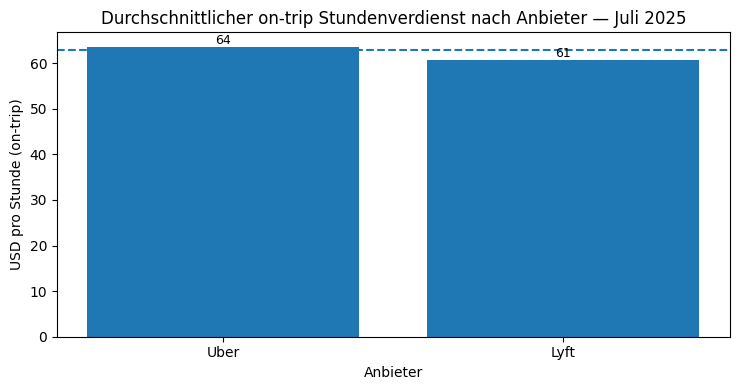

In [ ]:
prov_agg = (df
    .groupby("Providers", dropna=False)
    .agg(trips=("earnings","count"),
         total_earnings=("earnings","sum"),
         total_hours=("trip_hours","sum"))
    .reset_index()
)

prov_agg["hourly_on_trip"] = prov_agg["total_earnings"] / prov_agg["total_hours"]
prov_agg = prov_agg.sort_values("hourly_on_trip", ascending=False)

plt.figure(figsize=(7.5,4))
plt.axhline(overall_hourly, linestyle="--")
plt.bar(prov_agg["Providers"].astype(str), prov_agg["hourly_on_trip"])
for i, v in enumerate(prov_agg["hourly_on_trip"]):
    plt.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9)
plt.title("Durchschnittlicher on-trip Stundenverdienst nach Anbieter — Juli 2025")
plt.ylabel("USD pro Stunde (on-trip)")
plt.xlabel("Anbieter")
plt.tight_layout()
plt.show()

## Tageszeit‑Profil (Stunden des Tages)
#### „Welche Wochentage lohnen sich am meisten?“

C:\Users\danie\AppData\Local\Temp\ipykernel_36024\2874130352.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(weighted_hourly)
C:\Users\danie\AppData\Local\Temp\ipykernel_36024\2874130352.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(weighted_hourly)


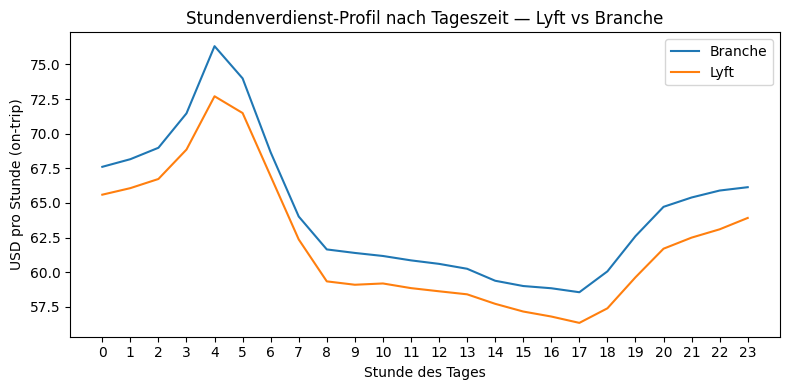

In [ ]:
provider_to_compare = "Lyft"  # <- bei Bedarf anpassen

hourly_prof_all = (df.groupby("hour")
                     .apply(weighted_hourly)
                     .rename("industry_hourly")
                     .reset_index())

hourly_prof_provider = (df[df["Providers"]==provider_to_compare]
                        .groupby("hour")
                        .apply(weighted_hourly)
                        .rename("provider_hourly")
                        .reset_index())

merged = pd.merge(hourly_prof_all, hourly_prof_provider, on="hour", how="outer")

plt.figure(figsize=(8,4))
plt.plot(merged["hour"], merged["industry_hourly"], label="Branche")
plt.plot(merged["hour"], merged["provider_hourly"], label=provider_to_compare)
plt.title(f"Stundenverdienst-Profil nach Tageszeit — {provider_to_compare} vs Branche")
plt.xlabel("Stunde des Tages")
plt.ylabel("USD pro Stunde (on-trip)")
plt.xticks(range(0,24))
plt.legend()
plt.tight_layout()
plt.show()


## Wochentags‑Vergleich
### „Welche Wochentage lohnen sich am meisten?“

C:\Users\danie\AppData\Local\Temp\ipykernel_36024\3780501222.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dow_industry = (df.groupby("dow").apply(weighted_hourly)
C:\Users\danie\AppData\Local\Temp\ipykernel_36024\3780501222.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .groupby("dow").apply(weighted_hourly)


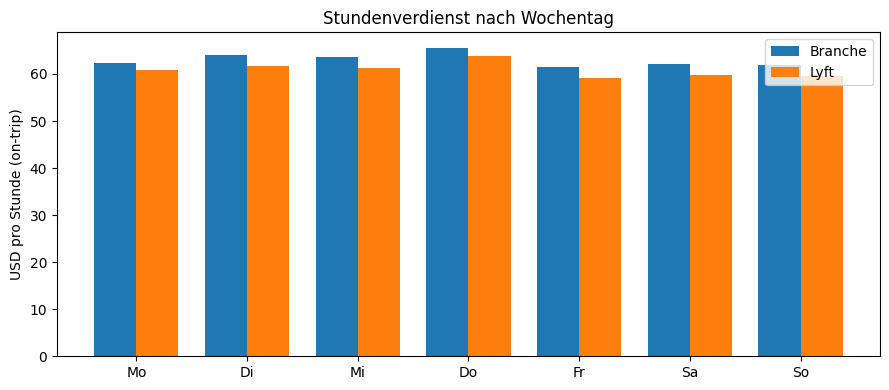

In [ ]:
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

dow_industry = (df.groupby("dow").apply(weighted_hourly)
                  .reindex(dow_order).rename("industry_hourly").reset_index())

dow_provider = (df[df["Providers"]==provider_to_compare]
                .groupby("dow").apply(weighted_hourly)
                .reindex(dow_order).rename("provider_hourly").reset_index())

dow_merged = pd.merge(dow_industry, dow_provider, on="dow", how="outer")

x = np.arange(len(dow_order))
width = 0.38
plt.figure(figsize=(9,4))
plt.bar(x - width/2, dow_merged["industry_hourly"], width, label="Branche")
plt.bar(x + width/2, dow_merged["provider_hourly"], width, label=provider_to_compare)
plt.xticks(x, ["Mo","Di","Mi","Do","Fr","Sa","So"])
plt.ylabel("USD pro Stunde (on-trip)")
plt.title("Stundenverdienst nach Wochentag")
plt.legend()
plt.tight_layout()
plt.show()


## Verteilungsblick (pro Fahrt)
### „Wie streuen die Einnahmen pro Fahrt je Anbieter?“

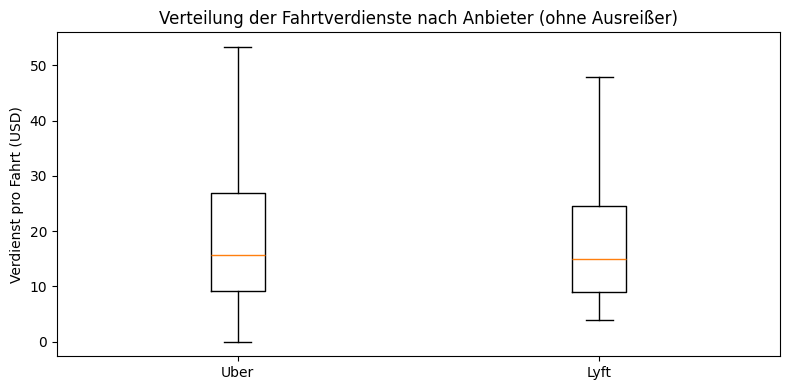

In [ ]:
labels = prov_agg["Providers"].astype(str).tolist()
data   = [df[df["Providers"] == p]["earnings"].dropna().values for p in labels]

plt.figure(figsize=(8, 4))
plt.boxplot(data, tick_labels=labels, showfliers=False)
plt.ylabel("Verdienst pro Fahrt (USD)")
plt.title("Verteilung der Fahrtverdienste nach Anbieter (ohne Ausreißer)")
plt.tight_layout()
plt.show()